<a href="https://colab.research.google.com/github/jerrinojacob/Data-Science-Portfolio/blob/main/Project_04/Pre_Release_Song_Popularity_Prediction_on_Spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 4 - Pre-Release Song Popularity Prediction on Spotify


##PROBLEM DEFINITION

Develop a **supervised regression model** to predict the **potential popularity** of unreleased songs on Spotify using pre-release features.

**Approach:**
- Leverage pre-release attributes from existing songs, excluding actual popularity scores from training data
- Implement Decision Tree, Random Forest and XGBoost regression algorithms
- Optimize model performance using RMSE metrics with strategic hyperparameter tuning to prevent overfitting
- Conduct feature importance analysis to identify key predictive characteristics

**Business Value:**
Enables data-driven marketing strategies and informed resource allocation for new music releases, advancing the application of predictive analytics in the music industry.

##DATA COLLECTION

#####Loading Libraries

In [64]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import matplotlib.colors as mcolors
import plotly.express as px

import seaborn as sns


from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn import metrics
import pickle

import graphviz
from IPython.display import display
from sklearn import tree

import statsmodels.api as sm

#####Loading Data

In [65]:
#Defining the URL and HTTP HEAD request
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
!curl -s -I {url}

HTTP/1.1 200 OK
x-amz-id-2: jPAcrEw67EsCuRUHJVZdcL/Vapd/j5MwZtlVKjEOdPBsHwlNAtrU07VNbxTwo48DWU5eA5plNjM=
x-amz-request-id: TSVAWVJ2R0M18XJS
Date: Mon, 03 Nov 2025 17:51:38 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [66]:
!curl -O {url}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  720k  100  720k    0     0  2631k      0 --:--:-- --:--:-- --:--:-- 2630k


In [67]:
#Lists the file downloaded in the local directory
!ls -lart

total 740
drwxr-xr-x 4 root root   4096 Oct 31 17:50 .config
drwxr-xr-x 1 root root   4096 Oct 31 17:50 sample_data
drwxr-xr-x 1 root root   4096 Nov  3 17:47 ..
drwxr-xr-x 1 root root   4096 Nov  3 17:48 .
-rw-r--r-- 1 root root 738124 Nov  3 17:51 Spotify.csv


In [68]:
#Identifying the type of file
!file Spotify.csv

Spotify.csv: CSV text


In [69]:
#Displaying the first 10 lines of the file and checking for any anomalies

#####Loading Data into Dataframe

In [70]:
#Identified there are blank spaces in some of the fields
#Replacing th specific columns with null values
#Also replacing the thousand separator, if any to return the column as a numerical column
spotify_df = pd.read_csv(url,thousands=',',na_values={7	:' ',8	:' ',9	:' ',10	:' ',11	:' ',12	:' ',13	:' ',14	:' ',15	:' ',16	:' ',17	:' ',18	:' ',19	:' ',20	:' ',21	:' ',22	:' '})

##DATA CLEANING

#####Examining Data

In [71]:
#Reading top 10 rows
spotify_df.head(10)

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',48633449,Måneskin,3377762.00,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",...,0.71,0.80,-4.81,0.05,0.13,0.36,134.00,211560.00,0.59,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),47248719,The Kid LAROI,2230022.00,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],...,0.59,0.76,-5.48,0.05,0.04,0.10,169.93,141806.00,0.48,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,40162559,Olivia Rodrigo,6266514.00,4ZtFanR9U6ndgddUvNcjcG,['pop'],...,0.56,0.66,-5.04,0.15,0.34,0.08,166.93,178147.00,0.69,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,37799456,Ed Sheeran,83293380.00,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",...,0.81,0.90,-3.71,0.03,0.05,0.36,126.03,231041.00,0.59,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),33948454,Lil Nas X,5473565.00,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",...,0.74,0.70,-7.41,0.06,0.02,0.05,150.00,212000.00,0.89,D#/Eb
5,6,1,18,2021-05-07--2021-05-14,MONTERO (Call Me By Your Name),30071134,Lil Nas X,5473565.00,67BtfxlNbhBmCDR2L2l8qd,"['lgbtq+ hip hop', 'pop rap']",...,0.61,0.51,-6.68,0.15,0.30,0.38,178.82,137876.00,0.76,G#/Ab
6,7,3,16,2021-05-14--2021-05-21,Kiss Me More (feat. SZA),29356736,Doja Cat,8640063.00,748mdHapucXQri7IAO8yFK,"['dance pop', 'pop']",...,0.76,0.70,-3.54,0.03,0.23,0.12,110.97,208867.00,0.74,G#/Ab
7,8,2,10,2021-06-18--2021-06-25,Todo De Ti,26951613,Rauw Alejandro,6080597.00,4fSIb4hdOQ151TILNsSEaF,"['puerto rican pop', 'trap latino']",...,0.78,0.72,-3.60,0.05,0.31,0.09,127.95,199604.00,0.34,D#/Eb
8,9,3,8,2021-06-18--2021-06-25,Yonaguni,25030128,Bad Bunny,36142273.00,2JPLbjOn0wPCngEot2STUS,"['latin', 'reggaeton', 'trap latino']",...,0.64,0.65,-4.60,0.12,0.28,0.14,179.95,206710.00,0.44,C#/Db
9,10,8,10,2021-07-02--2021-07-09,I WANNA BE YOUR SLAVE,24551591,Måneskin,3377762.00,4pt5fDVTg5GhEvEtlz9dKk,"['indie rock italiano', 'italian pop']",...,0.75,0.61,-4.01,0.04,0.00,0.18,132.51,173347.00,0.96,C#/Db


In [72]:
#Reading last 10 rows
spotify_df.tail(10)

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
1546,1547,143,1,2019-12-27--2020-01-03,JACKBOYS,5363493,JACKBOYS,437907.00,62zKJrpbLxz6InR3tGyr7o,"['rap', 'trap']",...,0.41,0.13,-25.17,0.03,0.90,0.11,123.34,46837.00,0.07,C
1547,1548,156,1,2019-12-27--2020-01-03,Combatchy (feat. MC Rebecca),5149797,"Anitta, Lexa, Luísa Sonza",10741972.00,2bPtwnrpFNEe8N7Q85kLHw,"['funk carioca', 'funk pop', 'pagode baiano', ...",...,0.83,0.73,-3.03,0.08,0.38,0.02,150.13,157600.00,0.60,C#/Db
1548,1549,178,1,2019-12-27--2020-01-03,Old Town Road,4852004,Lil Nas X,5488666.00,2YpeDb67231RjR0MgVLzsG,"['lgbtq+ hip hop', 'pop rap']",...,0.88,0.62,-5.56,0.10,0.05,0.11,136.04,157067.00,0.64,F#/Gb
1549,1550,187,1,2019-12-27--2020-01-03,Let Me Know (I Wonder Why Freestyle),4701532,Juice WRLD,19102888.00,3wwo0bJvDSorOpNfzEkfXx,"['chicago rap', 'melodic rap']",...,0.64,0.54,-7.89,0.08,0.17,0.42,125.03,215381.00,0.38,G
1550,1551,190,1,2019-12-27--2020-01-03,Ne reviens pas,4676857,"Gradur, Heuss L'enfoiré",1390813.00,4TnFANpjVwVKWzkxNzIyFH,"['francoton', 'french hip hop', 'pop urbaine',...",...,0.93,0.78,-3.38,0.06,0.21,0.17,125.00,188613.00,0.93,A#/Bb
1551,1552,195,1,2019-12-27--2020-01-03,New Rules,4630675,Dua Lipa,27167675.00,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",...,0.76,0.70,-6.02,0.07,0.00,0.15,116.07,209320.00,0.61,A
1552,1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,4623030,Jorge & Mateus,15019109.00,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",...,0.53,0.87,-3.12,0.09,0.24,0.33,152.37,181930.00,0.71,B
1553,1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),4620876,Camila Cabello,22698747.00,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",...,0.77,0.52,-4.33,0.03,0.18,0.13,104.99,217307.00,0.39,D
1554,1555,198,1,2019-12-27--2020-01-03,Surtada - Remix Brega Funk,4607385,"Dadá Boladão, Tati Zaqui, OIK",208630.00,5F8ffc8KWKNawllr5WsW0r,"['brega funk', 'funk carioca']",...,0.83,0.55,-7.03,0.06,0.25,0.18,154.06,152784.00,0.88,F
1555,1556,199,1,2019-12-27--2020-01-03,Lover (Remix) [feat. Shawn Mendes],4595450,Taylor Swift,42227614.00,3i9UVldZOE0aD0JnyfAZZ0,"['pop', 'post-teen pop']",...,0.45,0.60,-7.18,0.06,0.43,0.09,205.27,221307.00,0.42,G


In [73]:
#Rows and columns count of the dataset
rows, cols = spotify_df.shape
print(f"In this dataset, there are \n- Rows: \t{rows}\n- Columns: \t{cols}");

In this dataset, there are 
- Rows: 	1556
- Columns: 	23


In [74]:
#Size of the dataset
print(f'Total Size of the dataset: {spotify_df.size:,}')

Total Size of the dataset: 35,788


In [75]:
#Detailed Summary of the dataframe
spotify_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Index                      1556 non-null   int64  
 1   Highest Charting Position  1556 non-null   int64  
 2   Number of Times Charted    1556 non-null   int64  
 3   Week of Highest Charting   1556 non-null   object 
 4   Song Name                  1556 non-null   object 
 5   Streams                    1556 non-null   int64  
 6   Artist                     1556 non-null   object 
 7   Artist Followers           1545 non-null   float64
 8   Song ID                    1545 non-null   object 
 9   Genre                      1545 non-null   object 
 10  Release Date               1545 non-null   object 
 11  Weeks Charted              1556 non-null   object 
 12  Popularity                 1545 non-null   float64
 13  Danceability               1545 non-null   float

In [76]:
#Dataframe columns
spotify_df.columns

Index(['Index', 'Highest Charting Position', 'Number of Times Charted',
       'Week of Highest Charting', 'Song Name', 'Streams', 'Artist',
       'Artist Followers', 'Song ID', 'Genre', 'Release Date', 'Weeks Charted',
       'Popularity', 'Danceability', 'Energy', 'Loudness', 'Speechiness',
       'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence',
       'Chord'],
      dtype='object')

Testing the codes
ignore this block of text

list(enumerate(spotify_df.columns))
pd.read_csv(url,usecols=[14,15],na_values={14:' ',15:' '}).value_counts(dropna=False).reset_index()
pd.read_csv(url,na_values={7	:' ',8	:' ',9	:' ',10	:' ',11	:' ',12	:' ',13	:' ',14	:' ',15	:' ',16	:' ',17	:' ',18	:' ',19	:' ',20	:' ',21	:' ',22	:' '}).value_counts(dropna=False).reset_index()


In [77]:
#Examining the number of numerical and categorical columns

numeric_cols_count=len(spotify_df.select_dtypes(include=['number']).columns)
categorical_cols_count = len(spotify_df.select_dtypes(include=['object']).columns)

print(f'There are {numeric_cols_count} numeric columns')
print(f'There are {categorical_cols_count} categorical columns')

numeric_cols = spotify_df.select_dtypes(include=['number']).columns
categorical_cols = spotify_df.select_dtypes(include=['object']).columns

There are 15 numeric columns
There are 8 categorical columns


In [78]:
#Stats of Numerical Columns
pd.set_option('display.float_format',  lambda x: '%.2f' % x)
spotify_df[numeric_cols].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Index,1556.00,778.50,449.32,1.00,389.75,778.50,1167.25,1556.00
Highest Charting Position,1556.00,87.74,58.15,1.00,37.00,80.00,137.00,200.00
Number of Times Charted,1556.00,10.67,16.36,1.00,1.00,4.00,12.00,142.00
Streams,1556.00,6340219.38,3369478.84,4176083.00,4915322.25,5275747.50,6455044.25,48633449.00
Artist Followers,1545.00,14716902.87,16675788.51,4883.00,2123734.00,6852509.00,22698747.00,83337783.00
Popularity,1545.00,70.09,15.82,0.00,65.00,73.00,80.00,100.00
Danceability,1545.00,0.69,0.14,0.15,0.60,0.71,0.80,0.98
Energy,1545.00,0.63,0.16,0.05,0.53,0.64,0.75,0.97
Loudness,1545.00,-6.35,2.51,-25.17,-7.49,-5.99,-4.71,1.51
Speechiness,1545.00,0.12,0.11,0.02,0.05,0.08,0.17,0.88


In [79]:
#Stats of Numerical Columns
spotify_df[categorical_cols].describe().transpose()

,count,unique,top,freq
Week of Highest Charting,1556,83,2019-12-27--2020-01-03,89
Song Name,1556,1556,Lover (Remix) [feat. Shawn Mendes],1
Artist,1556,716,Taylor Swift,52
Song ID,1545,1516,5uEYRdEIh9Bo4fpjDd4Na9,3
Genre,1545,394,[],75
Release Date,1545,477,2020-01-17,34
Weeks Charted,1556,775,2020-12-18--2020-12-25,32
Chord,1545,12,C#/Db,214


In [80]:
#Unique entries of Numerical columns
spotify_df[numeric_cols].nunique().sort_values(ascending=False)

,0
Index,1556
Streams,1556
Duration (ms),1485
Tempo,1460
Loudness,1393
Acousticness,964
Speechiness,771
Valence,731
Liveness,605
Artist Followers,599


In [81]:
#Unique entries of Catagorical columns
spotify_df[categorical_cols].nunique().sort_values(ascending=False)

,0
Song Name,1556
Song ID,1516
Weeks Charted,775
Artist,716
Release Date,477
Genre,394
Week of Highest Charting,83
Chord,12


#####Nulls Handling

In [82]:
# Null Values
spotify_df[numeric_cols].isna().sum().sort_values(ascending=False)

,0
Danceability,11
Popularity,11
Artist Followers,11
Acousticness,11
Speechiness,11
Loudness,11
Energy,11
Liveness,11
Tempo,11
Duration (ms),11


In [83]:
spotify_df[categorical_cols].isna().sum().sort_values(ascending=False)

,0
Song ID,11
Chord,11
Release Date,11
Genre,11
Artist,0
Song Name,0
Week of Highest Charting,0
Weeks Charted,0


In [84]:
spotify_df.isna().sum()[
    spotify_df.isna().sum() > 0
  ].sort_values(ascending=False)

,0
Artist Followers,11
Song ID,11
Genre,11
Release Date,11
Popularity,11
Danceability,11
Energy,11
Loudness,11
Speechiness,11
Acousticness,11


There are 11 nulls rows for these columns

In [85]:
print(f'{11/1556*100:.2f}%')

0.71%


* There is 0.71% rows of data with columns that have nulls, i.e., 11 of 1556 rows.
* DROP ROWS:
  - in 11 rows, most of the features including the target: popularity have nulls

#####Missing Data in Genre
* Genre = []

In [86]:
spotify_df['Genre'].value_counts()

,count
Genre,
[],75
"['dance pop', 'pop', 'post-teen pop']",71
"['latin', 'reggaeton', 'trap latino']",63
"['pop', 'post-teen pop']",57
"['melodic rap', 'philly rap', 'rap', 'trap']",33
...,...
"['basshall', 'turkish trap']",1
"['dance pop', 'edm', 'electro house', 'pop', 'pop dance', 'pop edm', 'tropical house']",1
"['dance pop', 'edm', 'pop', 'pop dance', 'post-teen pop', 'tropical house', 'uk pop']",1


In [87]:
#Checking what songs are showing with Genre=[]
empty_genre_rows = spotify_df[spotify_df['Genre'] == '[]']
empty_genre_rows[['Song Name','Artist','Genre']]

,Song Name,Artist,Genre
49,Build a Bitch,Bella Poarch,[]
51,Tiroteo - Remix,"Marc Seguí, Rauw Alejandro, Pol Granch",[]
56,Meu Pedaço de Pecado,João Gomes,[]
65,Don't Start Now,Dua Lipa,[]
66,Dinero,Trinidad Cardona,[]
...,...,...,...
1428,you should see me in a crown,Billie Eilish,[]
1451,Con Calma,"Daddy Yankee, Snow",[]
1455,King Of My City,A Boogie Wit da Hoodie,[]
1480,Look At Her Now,Selena Gomez,[]


In [88]:
print(f'There are 75 rows with Genre=[] and it constitues {75/1556*100:.2f}% of the total rows.')

There are 75 rows with Genre=[] and it constitues 4.82% of the total rows.


* DROP ROWS:
  - 75 rows of empty Genre must be dropped.
  - Only affect ~5% of data loss.

#####Target: Popularity

In [89]:
spotify_df['Popularity']

,Popularity
0,100.00
1,99.00
2,99.00
3,98.00
4,96.00
...,...
1551,79.00
1552,66.00
1553,81.00
1554,60.00


In [90]:
spotify_df['Popularity'].value_counts()

,count
Popularity,
75.00,67
76.00,66
72.00,64
77.00,62
80.00,58
...,...
46.00,1
36.00,1
34.00,1


In [91]:
spotify_df['Popularity'].describe()

,Popularity
count,1545.00
mean,70.09
std,15.82
min,0.00
25%,65.00
50%,73.00
75%,80.00
max,100.00


In [92]:
spotify_df['Popularity'].skew()

np.float64(-2.4683378758191634)

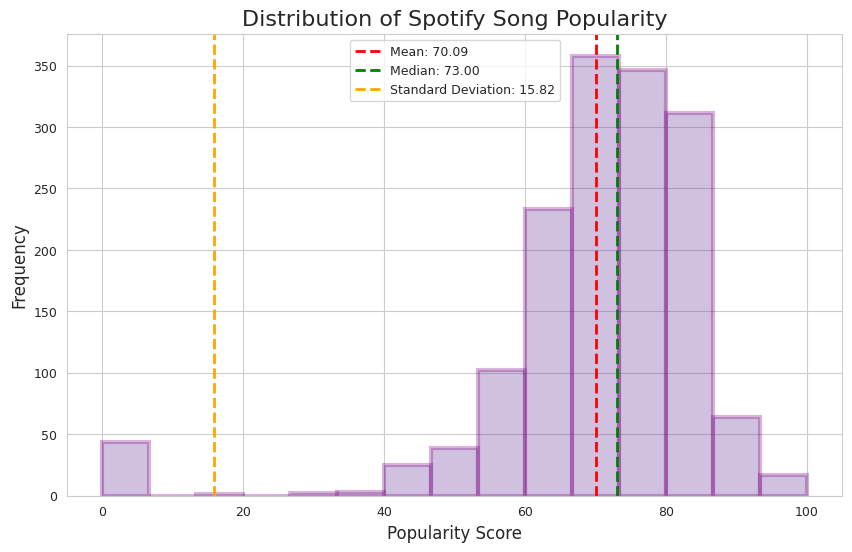

In [93]:
mean_val = spotify_df['Popularity'].mean()
median_val = spotify_df['Popularity'].median()
std_dev_val = spotify_df['Popularity'].std()

plt.figure(figsize=(10, 6))
spotify_df['Popularity'].hist(bins=15, color = 'rebeccapurple', edgecolor='purple', alpha=0.3, linewidth=3)
plt.title('Distribution of Spotify Song Popularity', fontsize=16)
plt.xlabel('Popularity Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)


plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_val:.2f}')
plt.axvline(std_dev_val, color='orange', linestyle='dashed', linewidth=2, label=f'Standard Deviation: {std_dev_val:.2f}')
plt.legend()

In [94]:
# # #Checking for Outliers - using Boxplot
# plt.figure(figsize=(8, 6))

# # # Generate the boxplot for the 'Popularity' column
# # # The `boxplot` function automatically calculates and shows outliers
# plt.boxplot(spotify_df['Popularity'])

# # # Add labels and a title for clarity
# plt.title('Boxplot of Spotify Song Popularity', fontsize=16)
# plt.ylabel('Popularity', fontsize=12)

Observation:
- Popularity is the target.
- It has continuous value 0 to 100.
- half the songs are above the 73 score (range: 0-100)
- Outliers are those below the bottom whiskers, i.e., songs with unusual low popularity
- distribution is left skewed.

#####BACKUPS & CLEANING

In [95]:
#Orignal Copy
spotify_original = spotify_df.copy()

In [96]:
#RESTORE ORIGINAL COPY
spotify_df=spotify_original.copy()
spotify_df.shape

(1556, 23)

In [97]:
#Original Numerical Copy
spotify_num_copy = spotify_df[numeric_cols].copy()

In [98]:
#Original Categorical Copy
spotify_cat_copy = spotify_df[categorical_cols].copy()

In [99]:
#Copy with Nulls
spotify_na_copy=spotify_df.copy()
spotify_na_copy.shape

(1556, 23)

In [100]:
#Eliminate the nulls
spotify_df=spotify_na_copy.copy() #Restore to the copy
spotify_df.dropna(how='any', axis=0, inplace=True)
spotify_df.shape

(1545, 23)

In [101]:
#Backup copy before eliminating the Genre=[]
spotify_genre_df = spotify_df.copy()
spotify_genre_df.shape
#spotify_df=spotify_genre_df.copy() #Restore to backup


(1545, 23)

In [102]:
#Eliminate the rows with Genre=[]
df = spotify_df[spotify_df['Genre'] != '[]'].copy()
print(df.shape)
spotify_df=df.copy()
spotify_df.shape

(1470, 23)


(1470, 23)

In [103]:
#Cross Checking if the rows eliminated
spotify_df['Genre'].value_counts()

,count
Genre,
"['dance pop', 'pop', 'post-teen pop']",71
"['latin', 'reggaeton', 'trap latino']",63
"['pop', 'post-teen pop']",57
"['melodic rap', 'philly rap', 'rap', 'trap']",33
"['chicago rap', 'melodic rap']",32
...,...
"['basshall', 'turkish trap']",1
"['dance pop', 'edm', 'electro house', 'pop', 'pop dance', 'pop edm', 'tropical house']",1
"['dance pop', 'edm', 'pop', 'pop dance', 'post-teen pop', 'tropical house', 'uk pop']",1


* Dropped 11 rows with columns having nulls
* Dropped 75 row where Genre was empty; they must be a human data entry error

* DROP COLUMNS - NUMERICAL
  - 'Index'
  - 'Highest Charting Position'

* DROP COLUMNS - CATEGORICAL
  - 'Week of Highest Charting'
  - 'Song ID'
  - 'Weeks Charted'
  - 'Release Date'

In [104]:
columns_to_drop = [
    'Index',
    'Highest Charting Position',
    'Week of Highest Charting',
    'Song ID',
    'Weeks Charted',
    'Release Date'
]
columns_to_drop

['Index',
 'Highest Charting Position',
 'Week of Highest Charting',
 'Song ID',
 'Weeks Charted',
 'Release Date']

* drop additional columns that may not be useful in the modeling

In [105]:
#drop additional columns that may not be useful in the modeling
#backup
spotify_predrop_df = spotify_df.copy()
spotify_df.shape

#spotify_df =spotify_predrop_df.copy()#RESTORE

(1470, 23)

In [106]:
#dropping columns
spotify_df.drop(columns=columns_to_drop, inplace=True)
spotify_df.shape

(1470, 17)

#####Categorical columns

In [107]:
categorical_cols = spotify_df.select_dtypes(include=['object']).columns
spotify_cat_df = spotify_df[categorical_cols]
spotify_cat_df

,Song Name,Artist,Genre,Chord
0,Beggin',Måneskin,"['indie rock italiano', 'italian pop']",B
1,STAY (with Justin Bieber),The Kid LAROI,['australian hip hop'],C#/Db
2,good 4 u,Olivia Rodrigo,['pop'],A
3,Bad Habits,Ed Sheeran,"['pop', 'uk pop']",B
4,INDUSTRY BABY (feat. Jack Harlow),Lil Nas X,"['lgbtq+ hip hop', 'pop rap']",D#/Eb
...,...,...,...,...
1551,New Rules,Dua Lipa,"['dance pop', 'pop', 'uk pop']",A
1552,Cheirosa - Ao Vivo,Jorge & Mateus,"['sertanejo', 'sertanejo universitario']",B
1553,Havana (feat. Young Thug),Camila Cabello,"['dance pop', 'electropop', 'pop', 'post-teen ...",D
1554,Surtada - Remix Brega Funk,"Dadá Boladão, Tati Zaqui, OIK","['brega funk', 'funk carioca']",F


##EXPLORATORY DATA ANALYSIS

#####Correlation Matrix

In [108]:
# Running Correlation Matrix on Numerical Data
numeric_cols = spotify_df.select_dtypes(include=['number']).columns
spotify_num_df = spotify_df[numeric_cols]
spotify_num_df

,Number of Times Charted,Streams,Artist Followers,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence
0,8,48633449,3377762.00,100.00,0.71,0.80,-4.81,0.05,0.13,0.36,134.00,211560.00,0.59
1,3,47248719,2230022.00,99.00,0.59,0.76,-5.48,0.05,0.04,0.10,169.93,141806.00,0.48
2,11,40162559,6266514.00,99.00,0.56,0.66,-5.04,0.15,0.34,0.08,166.93,178147.00,0.69
3,5,37799456,83293380.00,98.00,0.81,0.90,-3.71,0.03,0.05,0.36,126.03,231041.00,0.59
4,1,33948454,5473565.00,96.00,0.74,0.70,-7.41,0.06,0.02,0.05,150.00,212000.00,0.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551,1,4630675,27167675.00,79.00,0.76,0.70,-6.02,0.07,0.00,0.15,116.07,209320.00,0.61
1552,1,4623030,15019109.00,66.00,0.53,0.87,-3.12,0.09,0.24,0.33,152.37,181930.00,0.71
1553,1,4620876,22698747.00,81.00,0.77,0.52,-4.33,0.03,0.18,0.13,104.99,217307.00,0.39
1554,1,4607385,208630.00,60.00,0.83,0.55,-7.03,0.06,0.25,0.18,154.06,152784.00,0.88


In [109]:
#Creating a Correlation Matrix
spotify_corr = spotify_num_df.corr()

In [110]:
len(spotify_corr)

13

In [111]:
# Moving 'Popularity' to the front of the list

cols = spotify_corr.columns.tolist()
cols.remove('Popularity')
cols.insert(12, 'Popularity')
idx = spotify_corr.index.tolist()
idx.remove('Popularity')
idx.insert(0, 'Popularity')

spotify_corr = spotify_corr.reindex(columns=cols, index=cols)
spotify_corr

,Number of Times Charted,Streams,Artist Followers,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Popularity
Number of Times Charted,1.00,-0.06,0.04,0.02,-0.05,0.05,-0.07,0.04,-0.05,-0.05,0.04,0.02,0.46
Streams,-0.06,1.00,0.10,-0.09,0.00,-0.03,-0.06,0.04,0.04,0.06,0.02,0.03,0.14
Artist Followers,0.04,0.10,1.00,-0.11,-0.07,-0.04,-0.09,0.04,-0.02,-0.02,0.13,-0.10,0.00
Danceability,0.02,-0.09,-0.11,1.00,0.14,0.23,0.24,-0.32,-0.12,-0.03,-0.11,0.36,0.04
Energy,-0.05,0.00,-0.07,0.14,1.00,0.73,0.03,-0.54,0.12,0.11,0.06,0.35,0.11
Loudness,0.05,-0.03,-0.04,0.23,0.73,1.00,-0.01,-0.47,0.04,0.10,0.09,0.29,0.20
Speechiness,-0.07,-0.06,-0.09,0.24,0.03,-0.01,1.00,-0.14,0.08,0.12,-0.09,0.05,-0.10
Acousticness,0.04,0.04,0.04,-0.32,-0.54,-0.47,-0.14,1.00,-0.00,-0.07,-0.05,-0.09,-0.10
Liveness,-0.05,0.04,-0.02,-0.12,0.12,0.04,0.08,-0.00,1.00,-0.02,0.02,0.01,-0.09
Tempo,-0.05,0.06,-0.02,-0.03,0.11,0.10,0.12,-0.07,-0.02,1.00,-0.00,0.06,-0.04


######Heatmap - Correlation Matrix

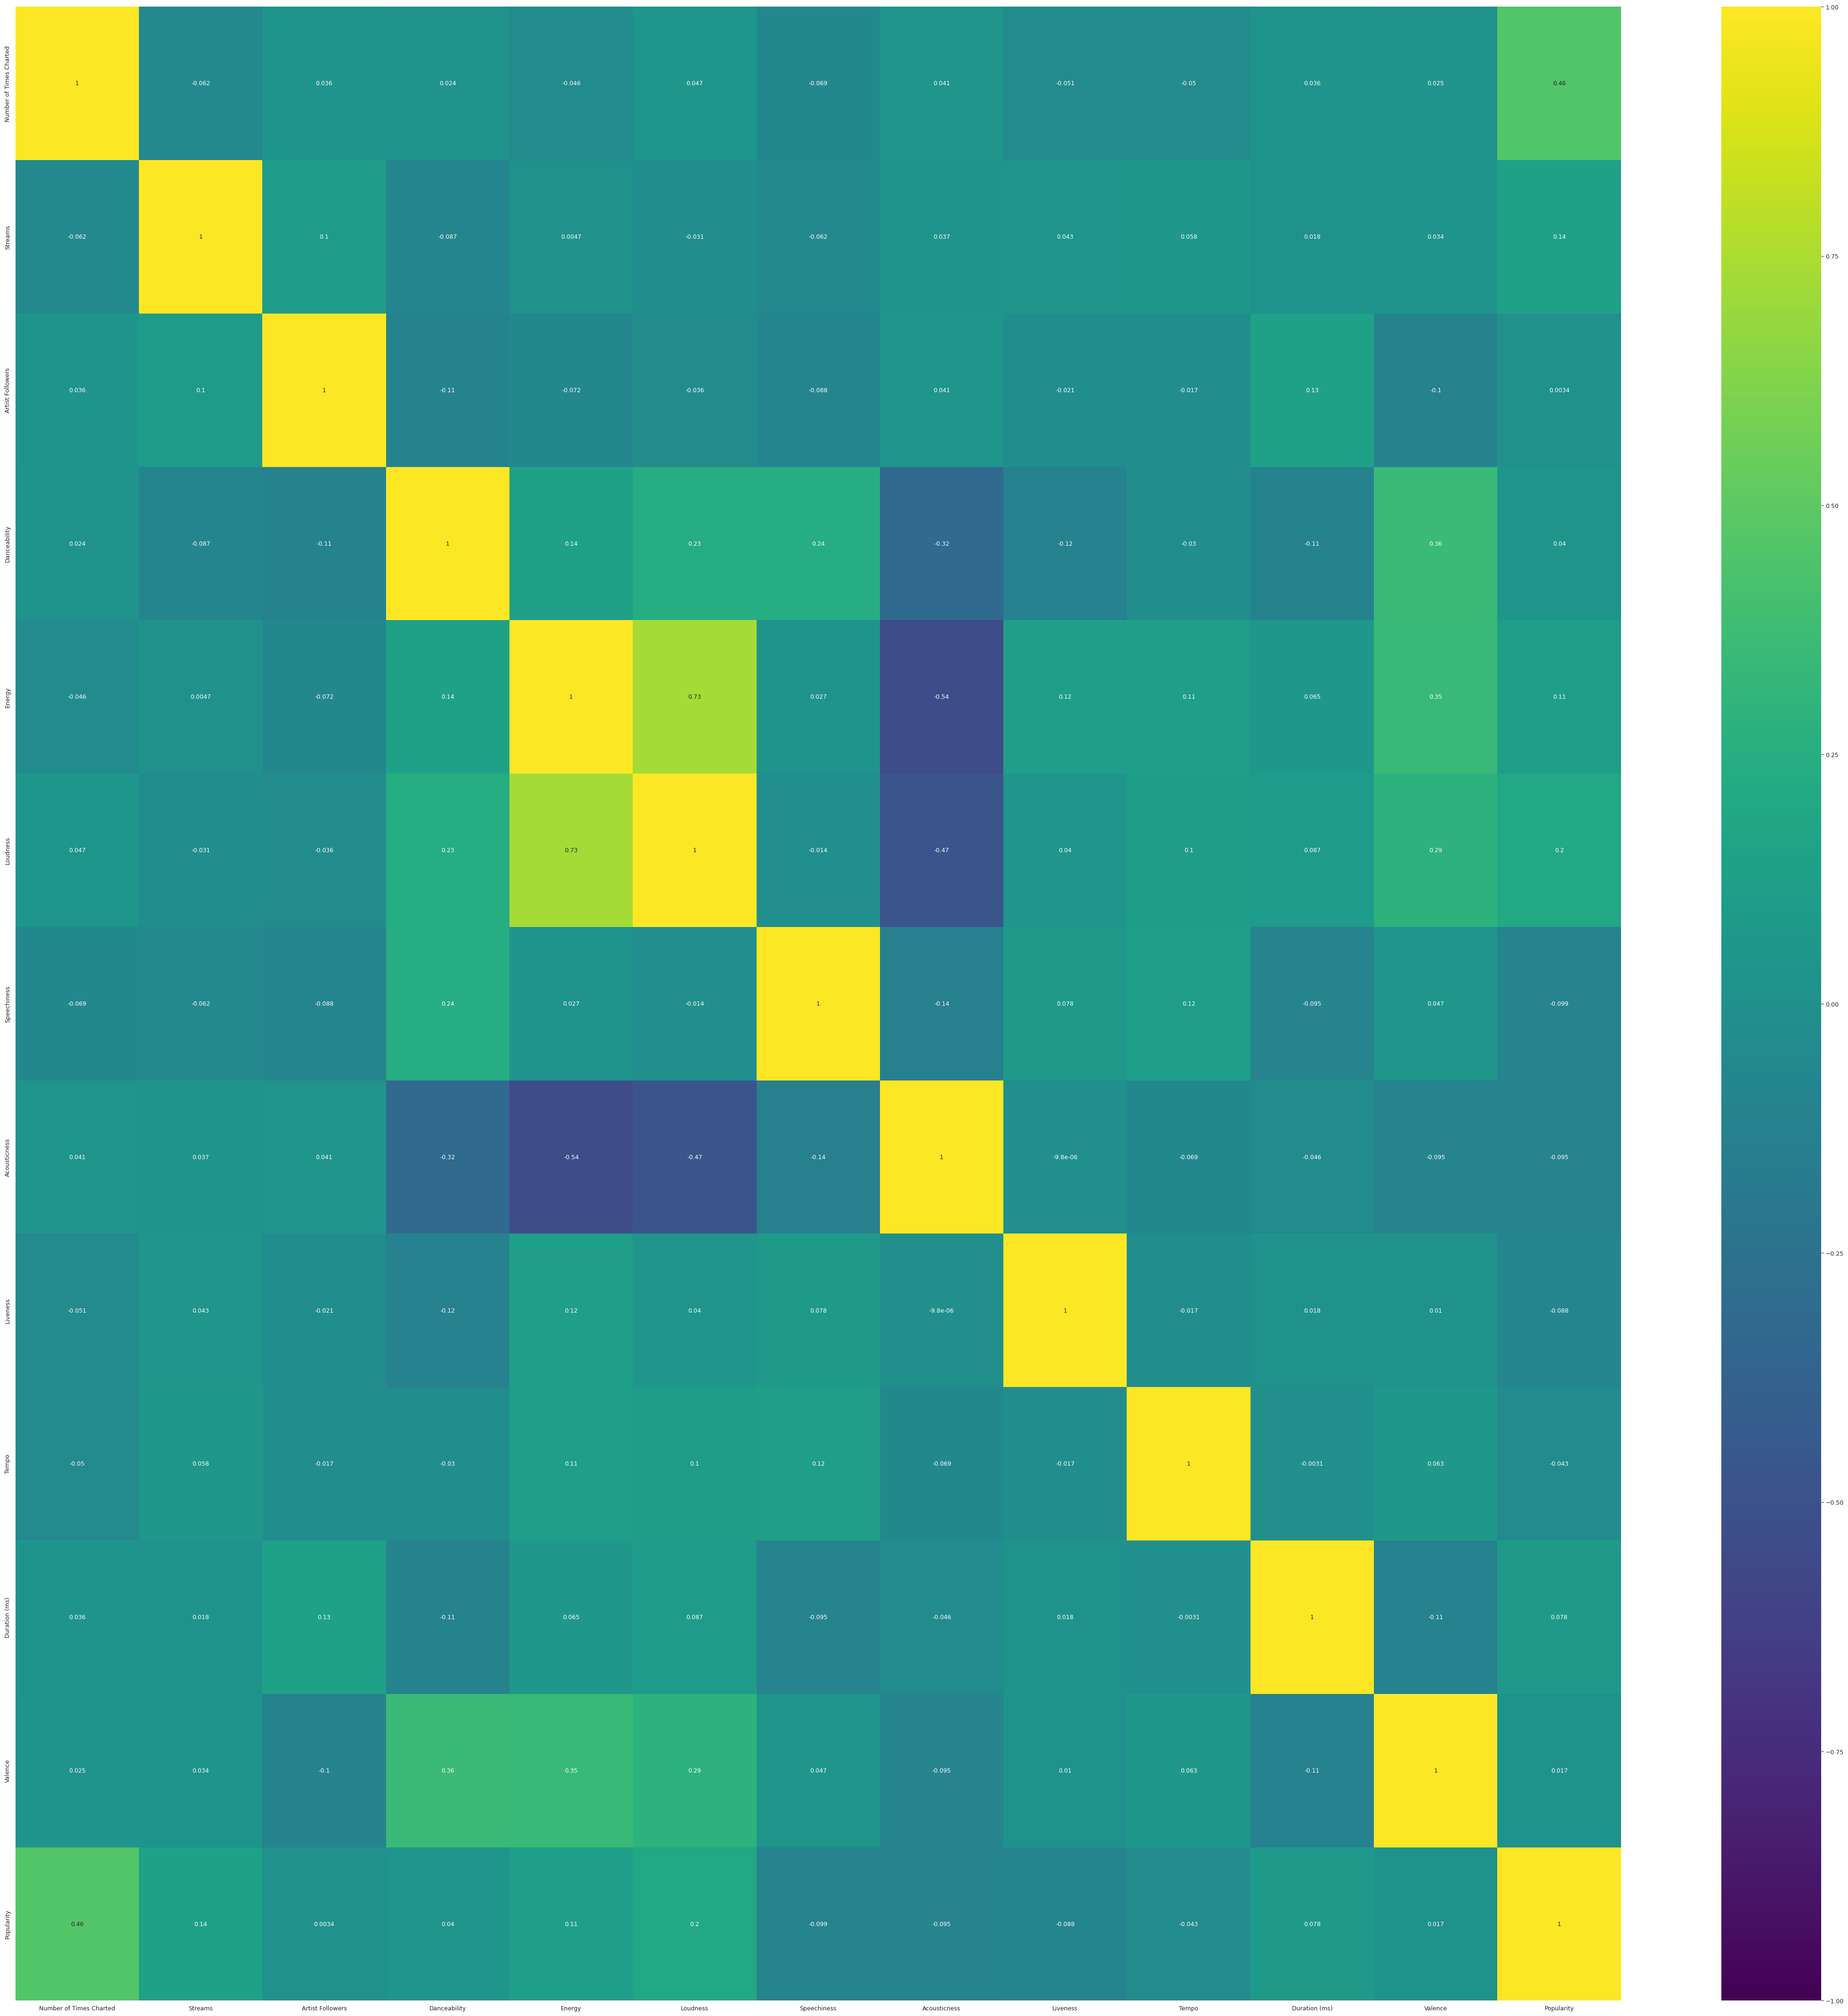

In [112]:
popularity_corr_row = spotify_corr.iloc[-1:]

plt.figure(figsize=(55,55))
sns.heatmap(
    spotify_corr,
    cmap='viridis',
    annot = True,
    vmin = -1,
    vmax = 1,
    );

######Histogram - Distribution & Skewness

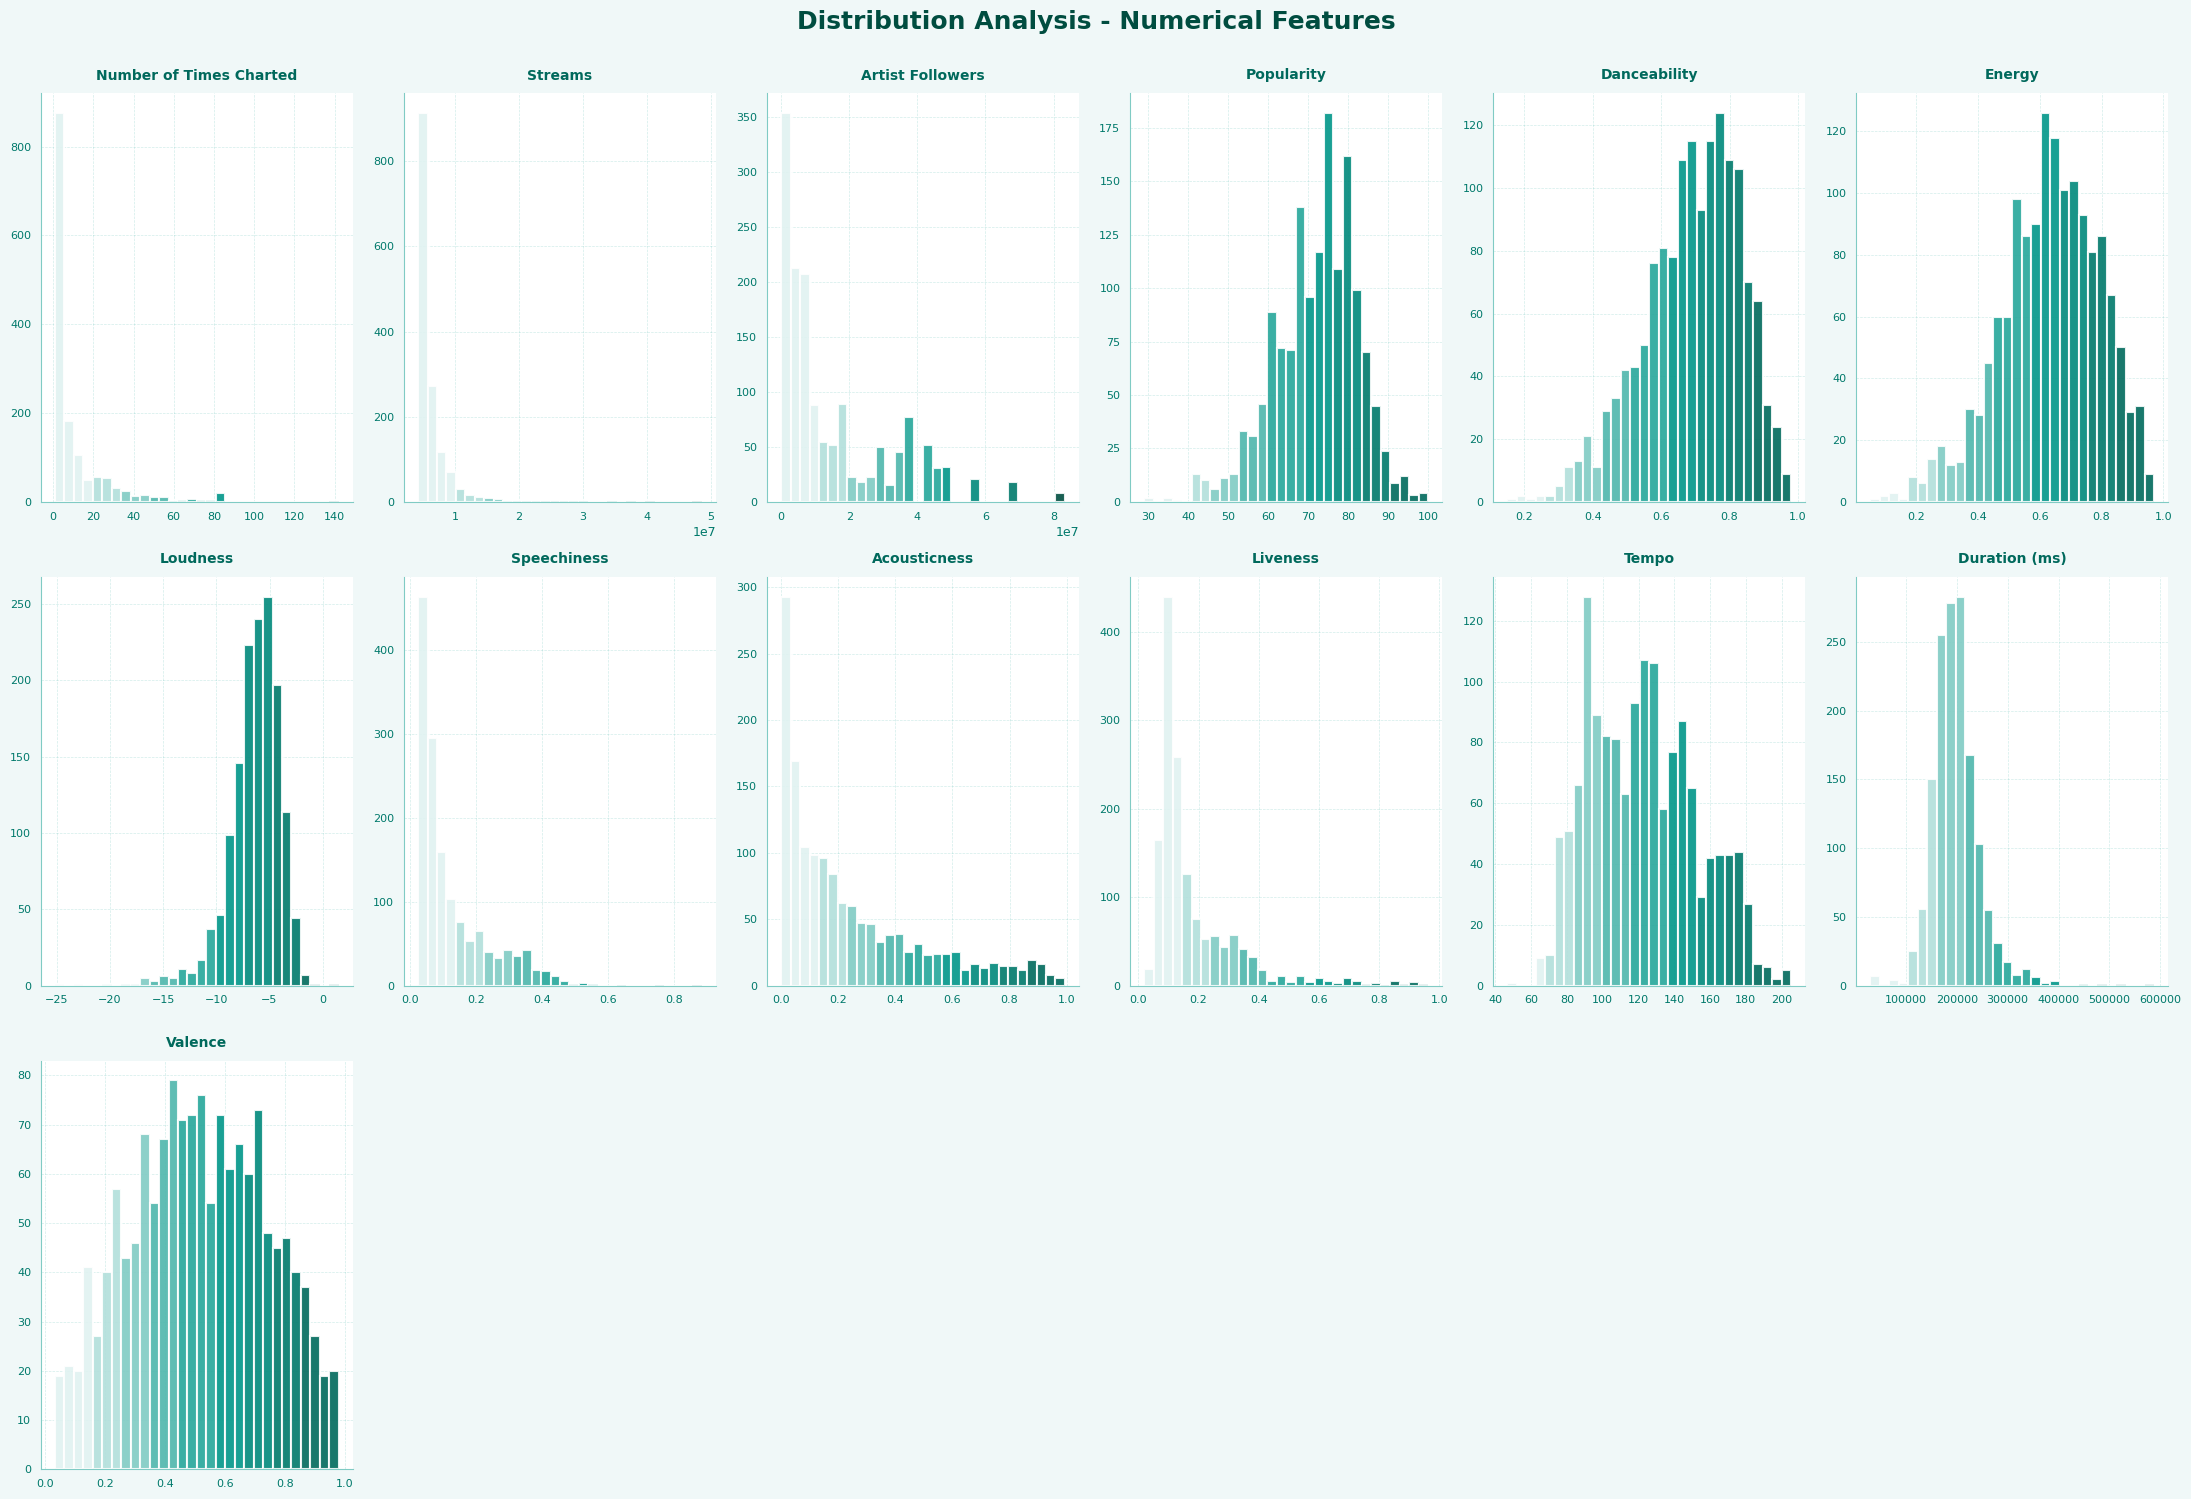

In [113]:
#Creating the Histogram
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 9

# Create figure with subplots
fig = plt.figure(figsize=(22, 15))
fig.patch.set_facecolor('#f0f8f8')

# Get numeric columns
numeric_cols = spotify_num_df.columns.tolist()

# Define teal color palette - gradient from light teal to deep teal
teal_colors = ['#E0F2F1', '#B2DFDB', '#80CBC4', '#4DB6AC', '#26A69A', '#009688', '#00897B', '#00796B', '#00695C', '#004D40']

# Create subplots
n_cols = 6
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

for idx, col in enumerate(numeric_cols):
    ax = plt.subplot(n_rows, n_cols, idx + 1)

    # Create histogram with teal gradient
    n, bins, patches = ax.hist(spotify_num_df[col].dropna(),bins=30,edgecolor='white',linewidth=1.5,alpha=0.9)

    # Apply teal gradient coloring to bars
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    col_norm = (bin_centers - bin_centers.min()) / (bin_centers.max() - bin_centers.min() + 1e-10)

    for c, p in zip(col_norm, patches):
        # Interpolate between light teal and deep teal
        color_idx = int(c * (len(teal_colors) - 1))
        plt.setp(p, 'facecolor', teal_colors[color_idx])

    # Styling
    ax.set_title(col, fontsize=10, fontweight='bold', pad=10, color='#00695C')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.5, color='#4DB6AC')
    ax.set_facecolor('#ffffff')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#80CBC4')
    ax.spines['bottom'].set_color('#80CBC4')

    # Format tick labels
    ax.tick_params(colors='#00796B', labelsize=8)

plt.suptitle('Distribution Analysis - Numerical Features', fontsize=18, fontweight='bold', y=0.995, color='#004D40')
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

#####Train-Test-Split

In [114]:
X = spotify_num_df.drop('Popularity', axis = 1)
y = spotify_num_df['Popularity']

##DATA PROCESSING

#####Linear Regression

In [115]:
#Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Scaling the Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Model:Linear Regression for training
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

#Creating Predictions
y_predict = linear_reg.predict(X_test)

#Calculating RMSE
def RMSE(y_actual, y_predict):
  return np.sqrt(np.mean(np.square(y_actual - y_predict)))

rmse_result = RMSE(y_test, y_predict)

print(f"RMSE:{rmse_result:.5f}")
print(f"Number of Predictors: {len(X.columns)}")

RMSE:8.82319
Number of Predictors: 12


#####Ridge Regression

In [118]:
#Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Scaling the Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Regularization with Ridge Regression
ridge = Ridge(alpha=1.0)  # Adjust alpha for regularization strength
ridge.fit(X_train, y_train)

#Creating Predictions
y_predict = ridge.predict(X_test)

#Calculating RMSE
def RMSE(y_actual, y_predict):
  return np.sqrt(np.mean(np.square(y_actual - y_predict)))

rmse_result = RMSE(y_test, y_predict)

print(f"RMSE:{rmse_result:.5f}")
print(f"Number of Predictors: {len(X.columns)}")

RMSE:8.82276
Number of Predictors: 12


#####Lasso Regression

In [121]:
#Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Scaling the Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Regularization with Lasso Regression
model = Lasso(alpha=1.0)  # Adjust alpha for regularization strength
model.fit(X_train, y_train)

#Creating Predictions
y_predict = model.predict(X_test)

#Calculating RMSE
def RMSE(y_actual, y_predict):
  return np.sqrt(np.mean(np.square(y_actual - y_predict)))

rmse_result = RMSE(y_test, y_predict)

print(f"RMSE:{rmse_result:.5f}")
print(f"Number of Predictors: {len(X.columns)}")

RMSE:8.90730
Number of Predictors: 12


#####Decision Tree Regression Modeling

In [124]:
#Decision Tree Regression

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

#Scaling the Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Decision Tree Model initiation
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train,y_train)

#Making Predictions
y_pred = model.predict(X_test)

#Calculating RMSE
def RMSE(y_actual, y_predict):
  return np.sqrt(np.mean(np.square(y_actual - y_predict)))

rmse = RMSE(y_test, y_predict)

print(f"Decision Tree RMSE: {rmse:.5f}")

Decision Tree RMSE: 8.90730


######Cross Validation

In [127]:
#CV Decision Tree
numLoops = 500  #CV repeats 500 times

rmse = np.zeros(numLoops)  #RMSE array for each iteration in loop

for idx in range(0, numLoops):

  #Train-Test-Split for each iteration
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

  #Decision Tree Model initiation
  model = DecisionTreeRegressor(max_depth = 5)
  model.fit(X_train, y_train)

  #Making Predictions
  y_pred = model.predict(X_test)

  #Calculating RMSE
  rmse[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE MEAN: {rmse.mean().round(5)}")

CV RMSE MEAN: 8.28879


######Decision Tree - Visualization

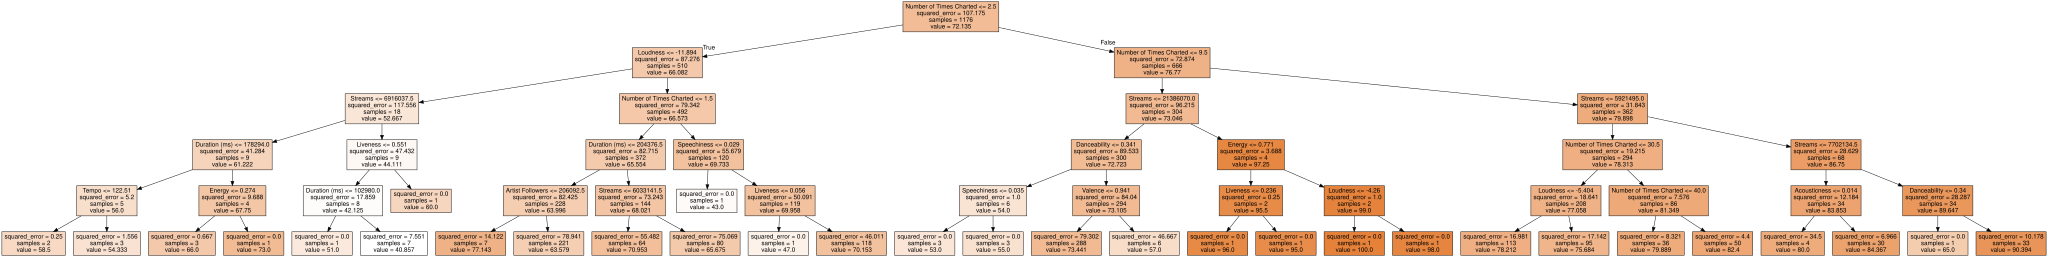

In [131]:
# Option 1
display(
  graphviz.Source(
    tree.export_graphviz(
      model,
      feature_names = X.columns,
      filled = True,
    )
  )
)

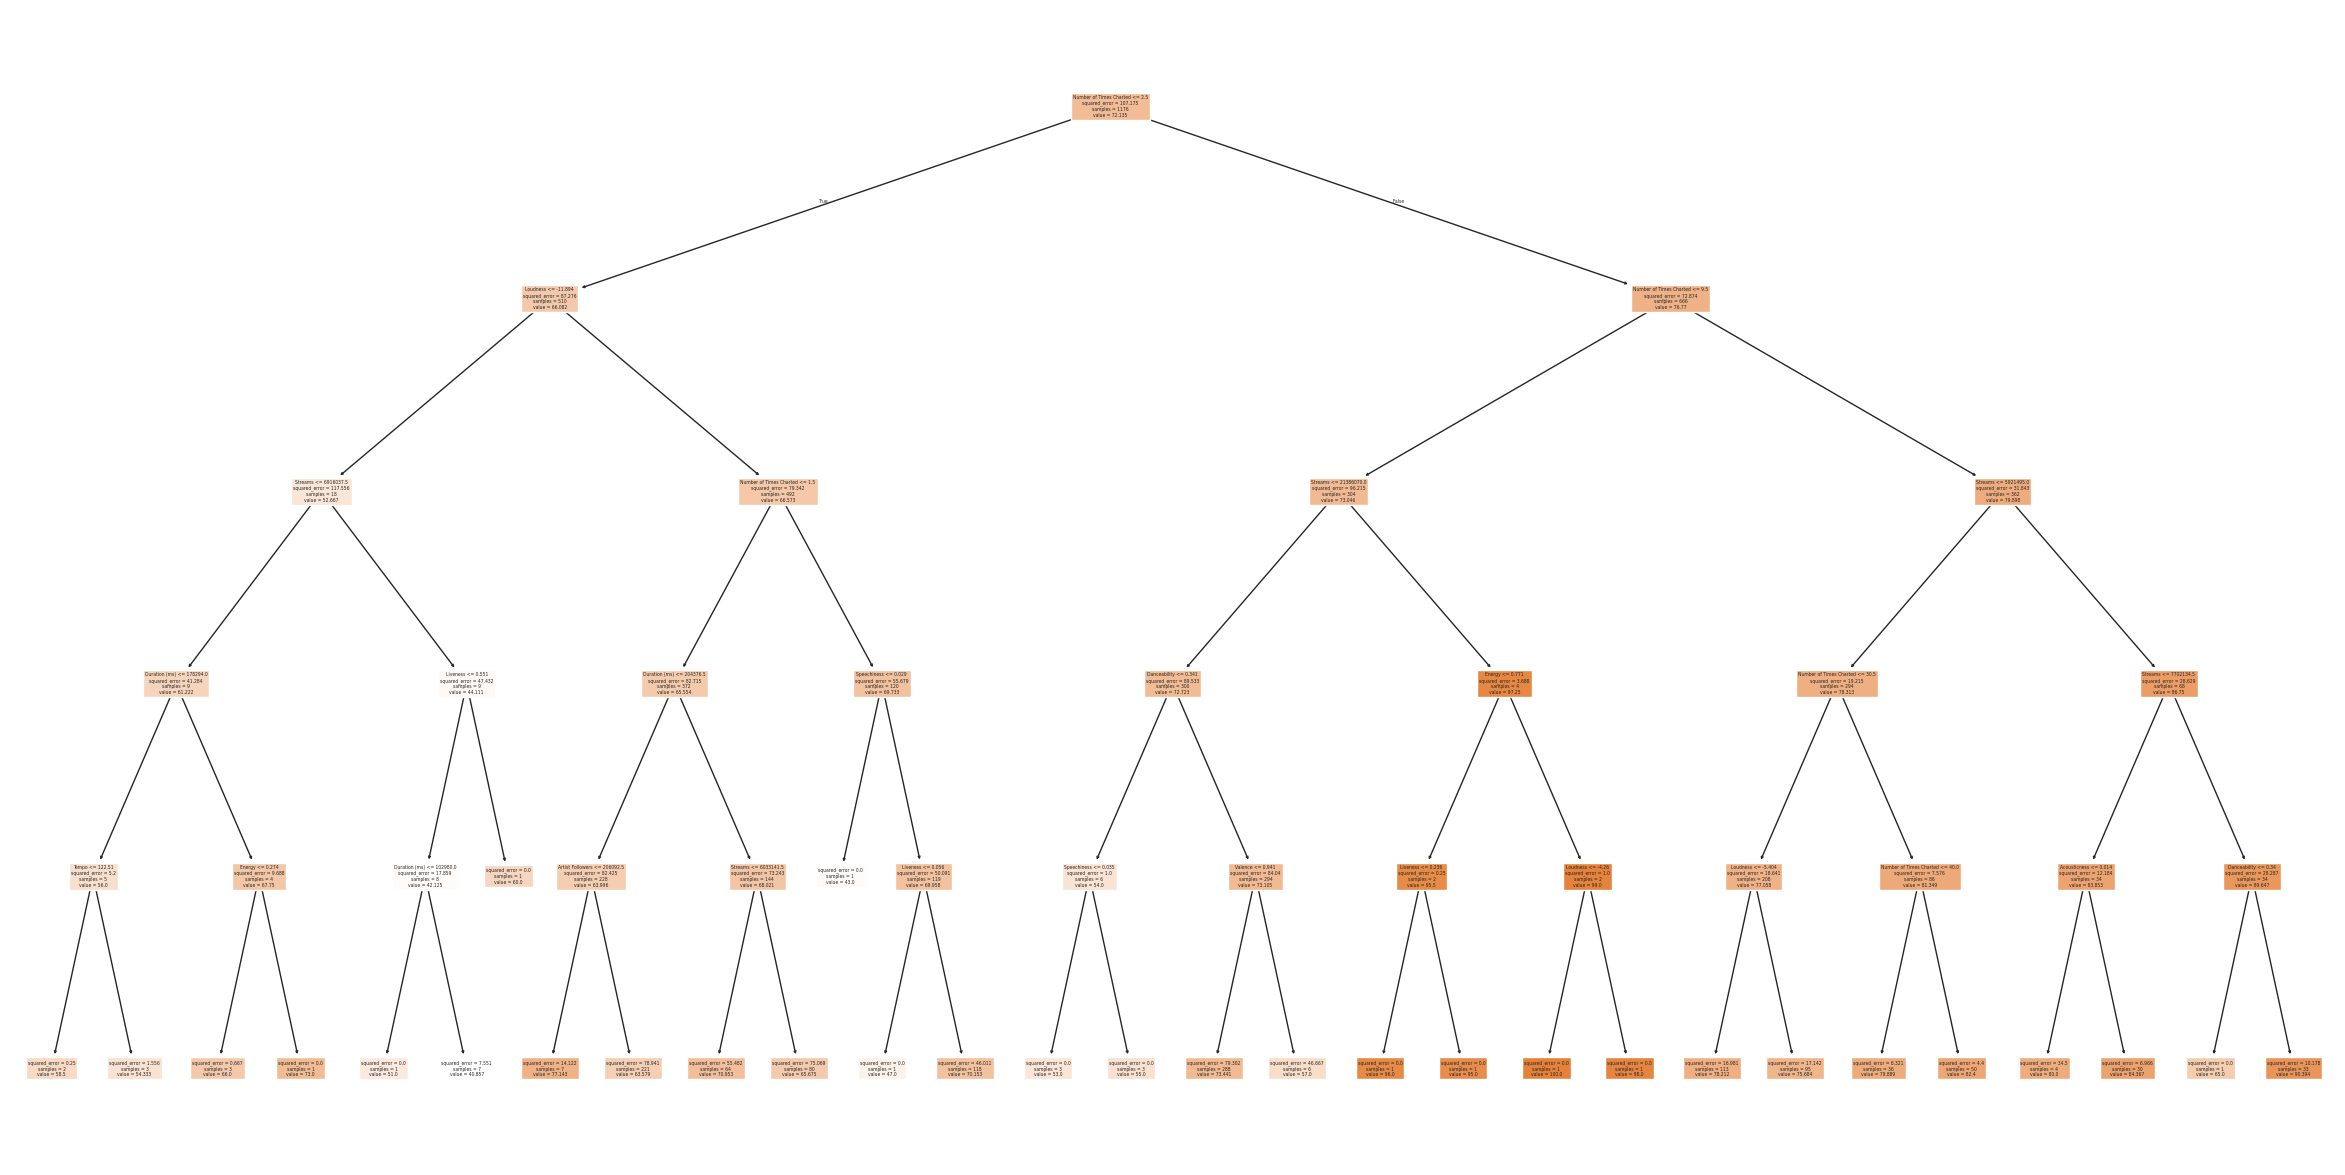

In [132]:
# Option 2: Decision Tree
plt.figure(figsize=(30,15))
tree_plot = tree.plot_tree(
  model,
  feature_names = X.columns,
  filled=True,
)

#####Random Forest Tree Regression Modeling

In [133]:
# Random Forest Regression

#Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

#Scaling the Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Decision Tree Model initiation
model = RandomForestRegressor(random_state=42)
model.fit(X_train,y_train)

#Making Predictions
y_pred = model.predict(X_test)

#Calculating RMSE
def RMSE(y_actual, y_predict):
  return np.sqrt(np.mean(np.square(y_actual - y_predict)))

rmse = RMSE(y_test, y_predict)

print(f"Random Forest Tree RMSE: {rmse:.5f}")

Random Forest Tree RMSE: 8.90730


######Cross Validation

In [136]:
#CV: Random Forest Regression

numLoops = 500  #CV repeats 500 times

rmse = np.zeros(numLoops)  #RMSE array for each iteration in loop

for idx in range(0, numLoops):

  #Train-Test-Split for each iteration
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

  ## Random Forest Regression Model initiation
  model = RandomForestRegressor(max_depth = 5)
  model.fit(X_train, y_train)

  #Making Predictions
  y_pred = model.predict(X_test)

  #Calculating RMSE
  rmse[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV Random Forest Regression RMSE MEAN: {rmse.mean().round(5)}")

CV Random Forest Regression RMSE MEAN: 7.64683


#####XGBoost Tree Regression Modeling

In [140]:
# XGBoost Regression

#Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

#Scaling the Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Decision Tree Model initiation
model = xgb.XGBRegressor(random_state=42)
model.fit(X_train,y_train)

#Making Predictions
y_pred = model.predict(X_test)

#Calculating RMSE
def RMSE(y_actual, y_predict):
  return np.sqrt(np.mean(np.square(y_actual - y_predict)))

rmse = RMSE(y_test, y_predict)

print(f"XGBoost Tree RMSE: {rmse:.5f}")

XGBoost Tree RMSE: 8.90730


######Cross Validation

In [143]:
#CV: XGBoost Regression

numLoops = 500  #CV repeats 500 times

rmse = np.zeros(numLoops)  #RMSE array for each iteration in loop

for idx in range(0, numLoops):

  #Train-Test-Split for each iteration
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

  ## XGBoost Tree Regression Model initiation
  model = xgb.XGBRegressor(objective ='reg:squarederror', verbosity=0, seed = 10)
  model.fit(X_train, y_train)

  #Making Predictions
  y_pred = model.predict(X_test)

  #Calculating RMSE
  rmse[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV XGBoost Tree Regression RMSE MEAN: {rmse.mean().round(5)}")

CV XGBoost Tree Regression RMSE MEAN: 7.76071


#####Feature Importance

In [147]:
feature_importance = model.feature_importances_
feature_importance

array([0.29140714, 0.11925562, 0.06371608, 0.05768197, 0.04001949,
       0.10374583, 0.06376412, 0.05465937, 0.05672497, 0.03660109,
       0.06266297, 0.04976142], dtype=float32)

In [148]:
feature_importance_df =  pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
feature_importance_df.sort_values(by = "Importance", ascending=False)

,Feature,Importance
0,Number of Times Charted,0.29
1,Streams,0.12
5,Loudness,0.10
6,Speechiness,0.06
2,Artist Followers,0.06
10,Duration (ms),0.06
3,Danceability,0.06
8,Liveness,0.06
7,Acousticness,0.05
11,Valence,0.05


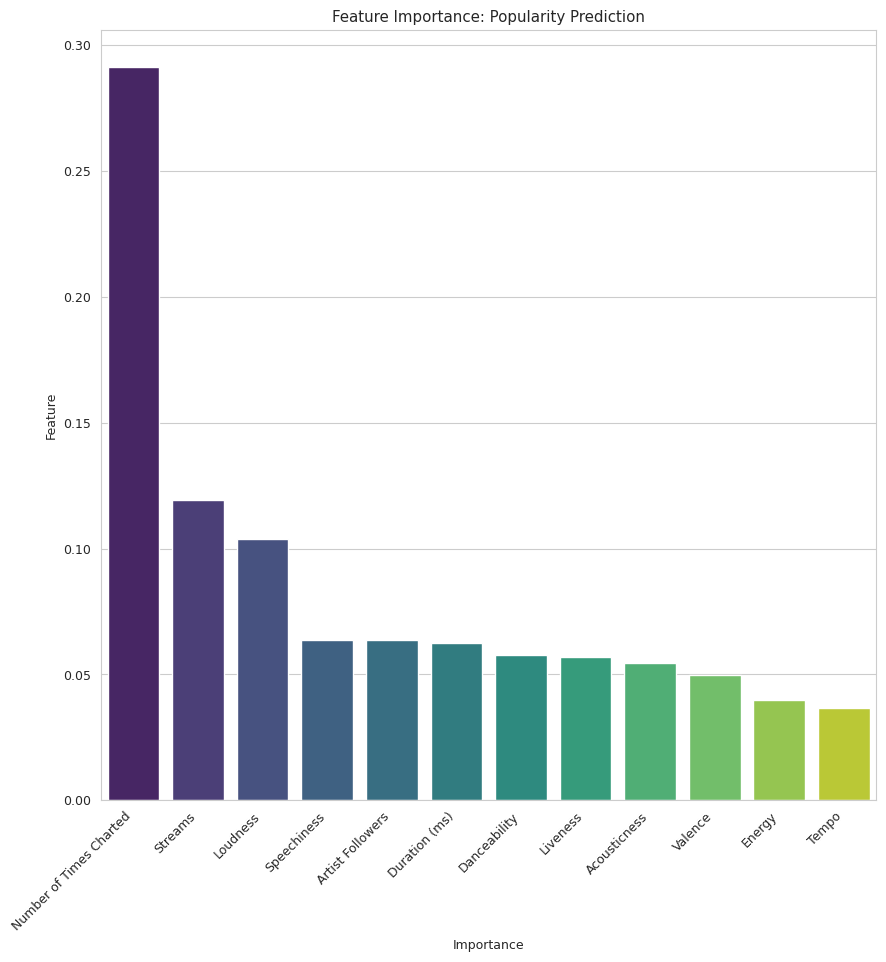

In [149]:
# Plot feature importance with rainbow colors
plt.figure(figsize=(10, 10))
sns.barplot(x='Feature', y='Importance', data=feature_importance_df.sort_values(by = "Importance", ascending=False), hue='Feature', dodge=False, legend=False, palette='viridis')
plt.title('Feature Importance: Popularity Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.show()

So I choose:
- Number of Times Charted
- Streams
- Loudness

In [154]:
fs_df = spotify_num_df[['Popularity','Number of Times Charted', 'Streams', 'Loudness']].copy()

In [155]:
fs_df.shape

(1470, 4)

#####Train-Test-Split

In [156]:
X = fs_df.drop('Popularity', axis = 1)
y = fs_df ['Popularity']

#####Decision Tree on Feature Select

In [157]:
#Decision Tree Regression

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

#Scaling the Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Decision Tree Model initiation
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train,y_train)

#Making Predictions
y_pred = model.predict(X_test)

#Calculating RMSE
def RMSE(y_actual, y_predict):
  return np.sqrt(np.mean(np.square(y_actual - y_predict)))

rmse = RMSE(y_test, y_predict)

print(f"Decision Tree RMSE: {rmse:.5f}")

Decision Tree RMSE: 8.90730


######Cross Validation

In [163]:
#CV Decision Tree
numLoops = 500  #CV repeats 500 times

rmse = np.zeros(numLoops)  #RMSE array for each iteration in loop

for idx in range(0, numLoops):

  #Train-Test-Split for each iteration
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

  #Decision Tree Model initiation
  model = DecisionTreeRegressor(max_depth = 4)
  model.fit(X_train, y_train)

  #Making Predictions
  y_pred = model.predict(X_test)

  #Calculating RMSE
  rmse[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE MEAN: {rmse.mean().round(5)}")

CV RMSE MEAN: 8.05695


#####Random Forest Tree Regression Modeling

In [164]:
# Random Forest Regression

#Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

#Scaling the Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Decision Tree Model initiation
model = RandomForestRegressor(random_state=42)
model.fit(X_train,y_train)

#Making Predictions
y_pred = model.predict(X_test)

#Calculating RMSE
def RMSE(y_actual, y_predict):
  return np.sqrt(np.mean(np.square(y_actual - y_predict)))

rmse = RMSE(y_test, y_predict)

print(f"Random Forest Tree RMSE: {rmse:.5f}")

Random Forest Tree RMSE: 8.90730


######Cross Validation

In [165]:
#CV: Random Forest Regression

numLoops = 500  #CV repeats 500 times

rmse = np.zeros(numLoops)  #RMSE array for each iteration in loop

for idx in range(0, numLoops):

  #Train-Test-Split for each iteration
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

  ## Random Forest Regression Model initiation
  model = RandomForestRegressor(max_depth = 5)
  model.fit(X_train, y_train)

  #Making Predictions
  y_pred = model.predict(X_test)

  #Calculating RMSE
  rmse[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV Random Forest Regression RMSE MEAN: {rmse.mean().round(5)}")

CV Random Forest Regression RMSE MEAN: 7.61439


#####XGBoost on Feature Select

In [159]:
# XGBoost Regression

#Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

#Scaling the Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Decision Tree Model initiation
model = xgb.XGBRegressor(random_state=42)
model.fit(X_train,y_train)

#Making Predictions
y_pred = model.predict(X_test)

#Calculating RMSE
def RMSE(y_actual, y_predict):
  return np.sqrt(np.mean(np.square(y_actual - y_predict)))

rmse = RMSE(y_test, y_predict)

print(f"XGBoost Tree RMSE: {rmse:.5f}")

XGBoost Tree RMSE: 8.90730


######Cross Validation

In [160]:
#CV: XGBoost Regression

numLoops = 500  #CV repeats 500 times

rmse = np.zeros(numLoops)  #RMSE array for each iteration in loop

for idx in range(0, numLoops):

  #Train-Test-Split for each iteration
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

  ## XGBoost Tree Regression Model initiation
  model = xgb.XGBRegressor(objective ='reg:squarederror', verbosity=0, seed = 10)
  model.fit(X_train, y_train)

  #Making Predictions
  y_pred = model.predict(X_test)

  #Calculating RMSE
  rmse[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV XGBoost Tree Regression RMSE MEAN: {rmse.mean().round(5)}")

CV XGBoost Tree Regression RMSE MEAN: 8.5862


##DATA VISUALIZATION

#####Actual vs Predicted

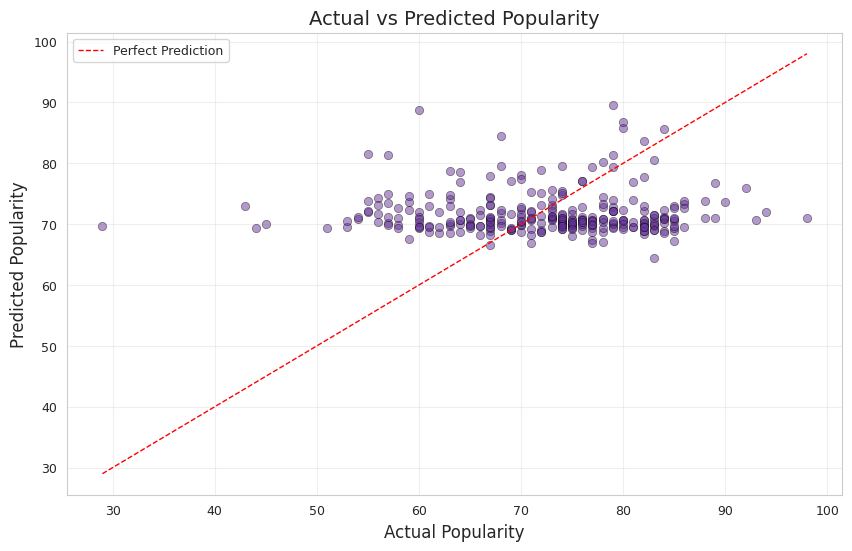

In [137]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_predict, alpha=0.5, color='rebeccapurple', edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1, label='Perfect Prediction')
plt.xlabel('Actual Popularity', fontsize=12)
plt.ylabel('Predicted Popularity', fontsize=12)
plt.title('Actual vs Predicted Popularity', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

#####Residual vs Predicted

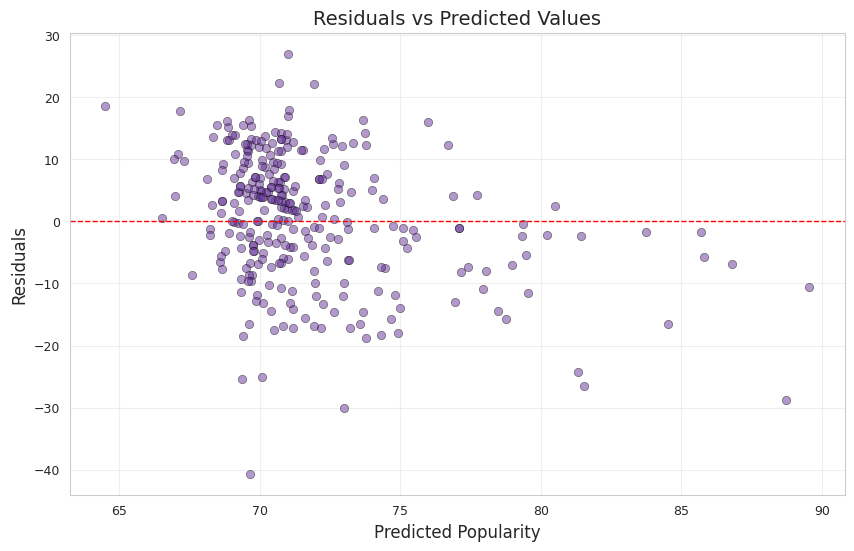

In [138]:
residuals = y_test - y_predict

plt.figure(figsize=(10, 6))
plt.scatter(y_predict, residuals, alpha=0.5, color='rebeccapurple', edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
plt.xlabel('Predicted Popularity', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Predicted Values', fontsize=14)
plt.grid(True, alpha=0.3)

#####QQ Plot

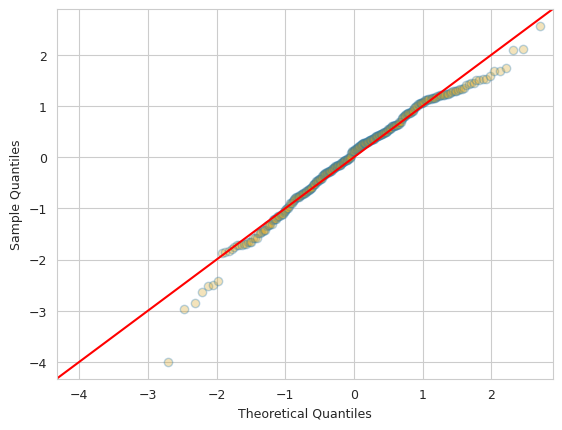

In [139]:
sm.qqplot(residuals, fit=True, line="45", alpha=0.3, markerfacecolor='goldenrod') ;